# scenario runner: plot modalities → run lcc discovery → plot result
- set `scenario` to one of: `scenario1` … `scenario6`
- this notebook loads `modalityX.csv` + `modalityX_dist.csv` from `./data/<scenario>/`
- it then runs `discover_lcc` and visualises lccs vs. noise in each modality

In [87]:
import os
import re
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, str(Path.cwd()))
from LCCdiscovery import LCCConfig, discover_lcc

In [88]:
scenario = 'scenario2'  #scenario1 to scenario6
alpha = 0.025
method = 'exact'  #exact or normal
fdr = 'bh'  #bh or by
min_component_size = 5
data_dir = Path.cwd() / 'data' / scenario
if not data_dir.exists():
    raise FileNotFoundError(f'data folder not found: {data_dir}')


In [89]:
def _find_modalities(folder: Path) -> list[int]:
    idxs = []
    for name in os.listdir(folder):
        m = re.fullmatch(r'modality(\d+)_dist\.csv', name)
        if m:
            idxs.append(int(m.group(1)))
    return sorted(idxs)
def load_scenario(folder: Path):
    idxs = _find_modalities(folder)
    if not idxs:
        raise FileNotFoundError('no modality*_dist.csv files found')
    modalities = {}
    dist_mats = []
    for k in idxs:
        data_path = folder / f'modality{k}.csv'
        dist_path = folder / f'modality{k}_dist.csv'
        data = np.genfromtxt(data_path, delimiter=',', names=True)
        #expected columns: id, modk_dim1, modk_dim2
        cols = [c for c in data.dtype.names if c != 'id']
        if len(cols) < 2:
            raise ValueError(f'{data_path} has <2 feature columns')
        xy = np.column_stack([data[cols[0]], data[cols[1]]]).astype(float)
        modalities[k] = xy
        d = np.loadtxt(dist_path, delimiter=',')
        dist_mats.append(d)
    n = next(iter(modalities.values())).shape[0]
    for k, xy in modalities.items():
        if xy.shape[0] != n:
            raise ValueError(f'modality{k} has n={xy.shape[0]}, expected {n}')
    for i, d in enumerate(dist_mats):
        if d.shape != (n, n):
            raise ValueError(f'dist matrix {i} has shape {d.shape}, expected {(n, n)}')
    return idxs, modalities, dist_mats
modality_idxs, modality_xy, dist_matrices = load_scenario(data_dir)
print('modalities:', modality_idxs)
print('n:', next(iter(modality_xy.values())).shape[0])

modalities: [1, 2, 3, 4]
n: 300


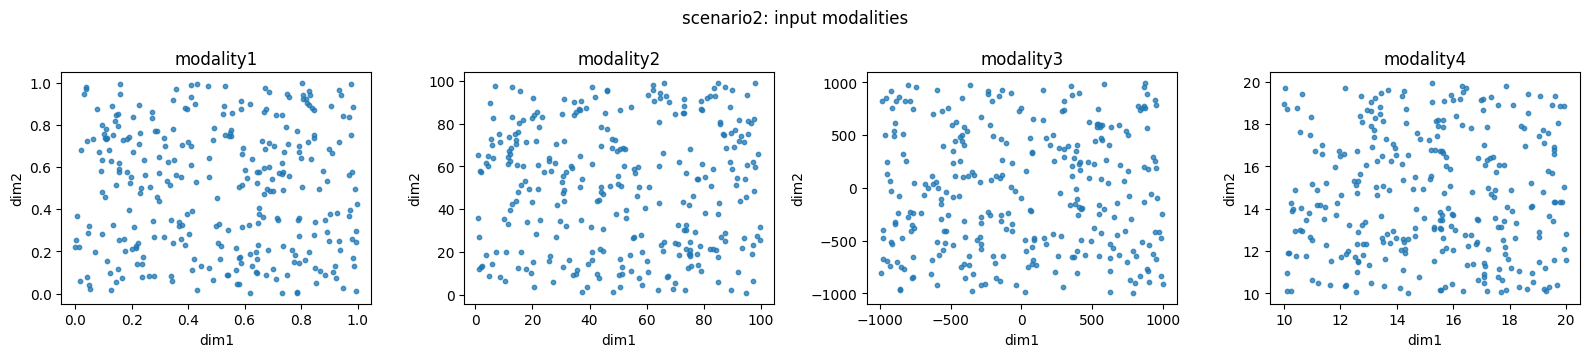

In [90]:
def plot_modalities(modalities: dict[int, np.ndarray], title: str):
    ks = sorted(modalities.keys())
    ncols = len(ks)
    fig, axes = plt.subplots(1, ncols, figsize=(4.0 * ncols, 3.6), squeeze=False)
    for idx, k in enumerate(ks):
        ax = axes[0][idx]
        xy = modalities[k]
        ax.scatter(xy[:, 0], xy[:, 1], s=10, alpha=0.75, color='tab:blue')
        ax.set_title(f'modality{k}')
        ax.set_xlabel('dim1')
        ax.set_ylabel('dim2')
    fig.suptitle(title)
    fig.tight_layout()
    return fig
plot_modalities(modality_xy, title=f'{scenario}: input modalities')
plt.show()

In [91]:
cfg = LCCConfig(alpha=alpha, method=method, fdr=fdr, min_component_size=min_component_size)
res = discover_lcc(dist_matrices, cfg)
print('n lccs (components):', len(res.components))
print('component sizes:', [len(c) for c in res.components])
print('n noise:', len(res.noise))
print('n mutual edges:', int(res.mutual_adjacency.sum() // 2))

n lccs (components): 1
component sizes: [5]
n noise: 295
n mutual edges: 13


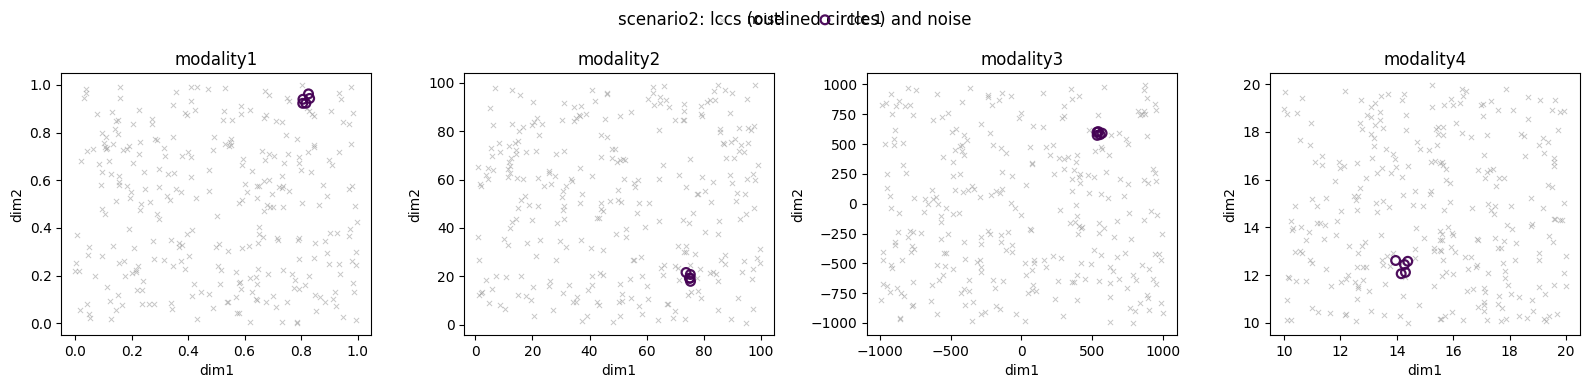

In [93]:
def labels_from_components(n: int, components: list[list[int]]) -> np.ndarray:
    labels = np.full(n, -1, dtype=int)
    for ci, comp in enumerate(components):
        labels[np.array(comp, dtype=int)] = ci
    return labels
def plot_result(modalities: dict[int, np.ndarray], labels: np.ndarray, title: str):
    ks = sorted(modalities.keys())
    if not ks:
        raise ValueError('no modalities to plot')
    ncols = len(ks)
    n_comp = int(labels.max() + 1)
    cmap = plt.get_cmap('viridis', max(n_comp, 1))
    fig, axes = plt.subplots(1, ncols, figsize=(4.0 * ncols, 3.9), squeeze=False)
    for idx, k in enumerate(ks):
        ax = axes[0][idx]
        xy = modalities[k]
        noise_mask = labels < 0
        ax.scatter(
            xy[noise_mask, 0],
            xy[noise_mask, 1],
            s=14,
            alpha=0.55,
            color='0.6',
            marker='x',
            linewidths=0.7,
            label='noise' if idx == 0 else None,
        )
        for ci in range(n_comp):
            mask = labels == ci
            if not np.any(mask):
                continue
            color = cmap(ci)
            ax.scatter(
                xy[mask, 0],
                xy[mask, 1],
                s=40,
                facecolors='none',
                edgecolors=[color],
                linewidths=1.6,
                marker='o',
                alpha=0.95,
                label=(f'lcc {ci + 1}' if idx == 0 else None),
            )
        ax.set_title(f'modality{k}')
        ax.set_xlabel('dim1')
        ax.set_ylabel('dim2')
    handles, labels_ = axes[0][0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels_, loc='upper center', ncol=min(8, len(handles)), frameon=False)
    fig.suptitle(title)
    fig.tight_layout()
    return fig
n = next(iter(modality_xy.values())).shape[0]
labels = labels_from_components(n, res.components)
plot_result(modality_xy, labels, title=f'{scenario}: lccs (outlined circles) and noise')
plt.show()